## Setup: Import Required Libraries
This cell loads all the Python libraries we need for data analysis and machine learning: pandas for data manipulation, matplotlib for plotting, and sklearn for building predictive models.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, r2_score

plt.style.use("ggplot")

## Data Loading and Preprocessing
Here we load the Zameen property dataset from a pipe-delimited CSV file and select the key columns we need: price, city, location, bedrooms, baths, and size. We clean the data by converting numeric columns and removing rows with missing values. Then we use one-hot encoding to convert city and location text fields into numerical features that machine learning models can use.

In [15]:
raw_data = pd.read_csv("data/zameen.csv", sep="|")
selected_columns = ["price", "city", "location", "bedrooms", "baths", "size"]
housing_data = raw_data[selected_columns].copy()

number_columns = ["price", "bedrooms", "baths", "size"]
housing_data[number_columns] = housing_data[number_columns].apply(pd.to_numeric, errors="coerce")
housing_data = housing_data.dropna(subset=["city", "location"] + number_columns).reset_index(drop=True)

model_data = pd.get_dummies(housing_data, columns=["city", "location"], dtype=int)

print("Cleaned Data Shape:", housing_data.shape)
print("Encoded Data Shape:", model_data.shape)
print("Cities in dataset:", housing_data["city"].nunique())
housing_data.head()

Cleaned Data Shape: (16019, 6)
Encoded Data Shape: (16019, 2052)
Cities in dataset: 11


,price,city,location,bedrooms,baths,size
0,74500000,Lahore,"DHA Phase 6, DHA Defence",5,6,4500.0
1,51500000,Lahore,"DHA Phase 7, DHA Defence",5,6,4500.0
2,7500000,Lahore,"Dream Gardens, Defence Road",1,1,518.0
3,73000000,Lahore,"DHA Phase 6, DHA Defence",5,6,4500.0
4,5700000,Lahore,"Bahria Town - Sector B, Bahria Town",1,1,472.0


## Exploratory Data Analysis
This section explores the dataset visually. First, we look at how house prices are distributed across all cities using a histogram. Then we create a scatter plot to see the relationship between house size and price. Finally, we display a bar chart of the top 10 most common city-location combinations in the dataset.

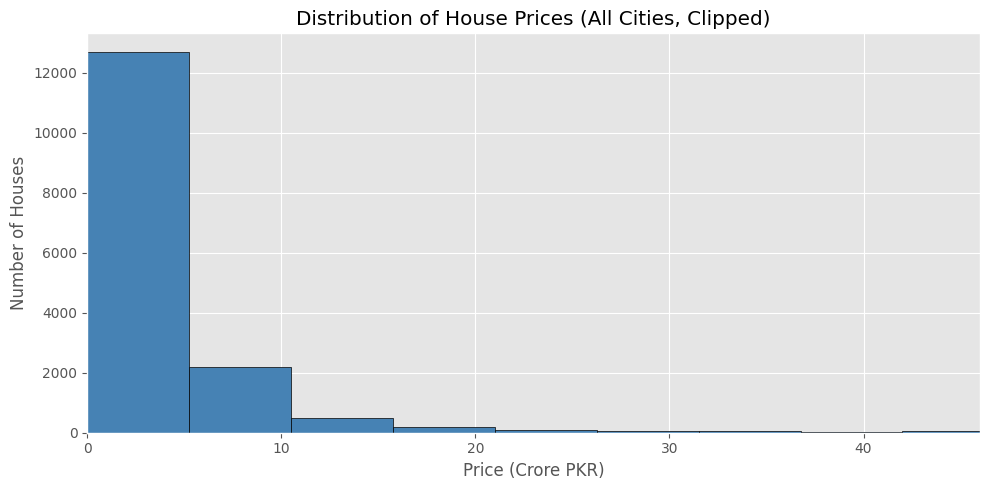

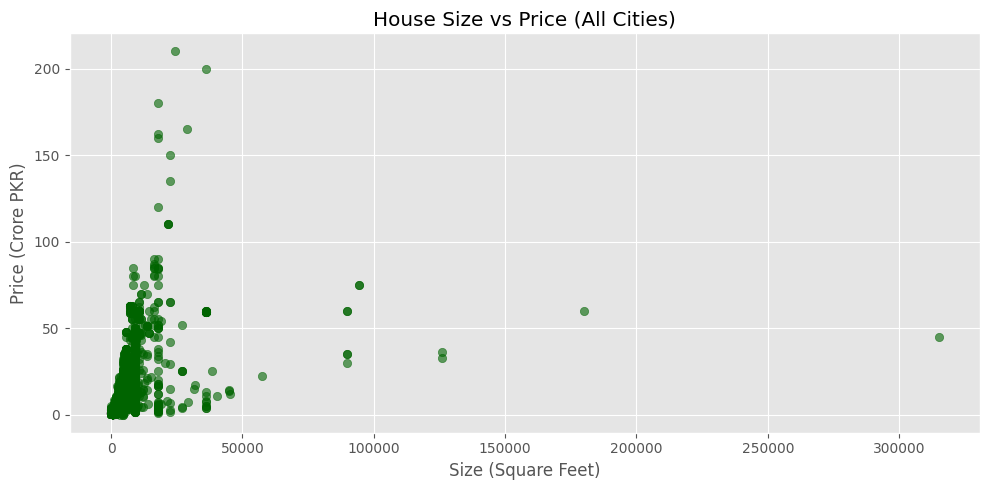

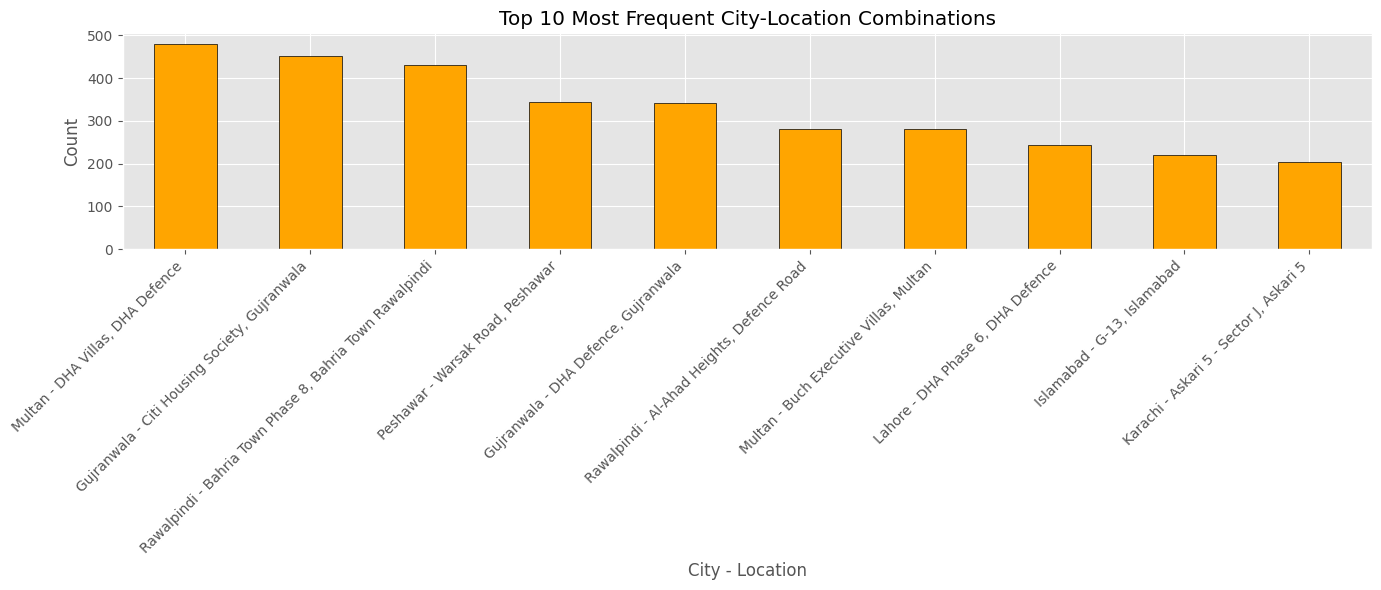

In [16]:
price_clip_limit = housing_data["price"].quantile(0.99)


def get_price_unit(max_price_value):
    if max_price_value >= 1e9:
        return 1e9, "Billion PKR"
    if max_price_value >= 1e7:
        return 1e7, "Crore PKR"
    if max_price_value >= 1e6:
        return 1e6, "Million PKR"
    if max_price_value >= 1e5:
        return 1e5, "Lakh PKR"
    if max_price_value >= 1e3:
        return 1e3, "Thousand PKR"
    return 1.0, "PKR"


price_unit_divider, price_unit_name = get_price_unit(price_clip_limit)
plot_prices = housing_data["price"] / price_unit_divider
plot_price_limit = price_clip_limit / price_unit_divider

plt.figure(figsize=(10, 5))
plt.hist(plot_prices, bins=40, color="steelblue", edgecolor="black")
plt.xlim(0, plot_price_limit)
plt.title("Distribution of House Prices (All Cities, Clipped)")
plt.xlabel(f"Price ({price_unit_name})")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(housing_data["size"], plot_prices, alpha=0.6, color="darkgreen")
plt.title("House Size vs Price (All Cities)")
plt.xlabel("Size (Square Feet)")
plt.ylabel(f"Price ({price_unit_name})")
plt.tight_layout()
plt.show()

city_location_text = housing_data["city"] + " - " + housing_data["location"]
top_city_location_counts = city_location_text.value_counts().head(10)

plt.figure(figsize=(14, 6))
top_city_location_counts.plot(kind="bar", color="orange", edgecolor="black")
plt.title("Top 10 Most Frequent City-Location Combinations")
plt.xlabel("City - Location")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Train-Test Split
We split our data into training and testing sets. The training set (80%) is used to teach our models, and the testing set (20%) is used to evaluate how well the models predict on unseen data.

In [17]:
feature_table = model_data.drop("price", axis=1)
target_prices = model_data["price"]

train_features, test_features, train_prices, test_prices = train_test_split(
    feature_table, target_prices, test_size=0.2, random_state=42
)

print("Training rows:", train_features.shape[0])
print("Testing rows:", test_features.shape[0])
print("Number of features:", train_features.shape[1])

Training rows: 12815
Testing rows: 3204
Number of features: 2051


## Linear Regression Model
We train a simple linear regression model to predict house prices based on all our features. Linear regression tries to find a straight-line relationship between the input features and the price. We evaluate it using Mean Absolute Error (MAE) and R-squared metrics.

In [18]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(train_features, train_prices)

linear_test_predictions = linear_regression_model.predict(test_features)
linear_mae = mean_absolute_error(test_prices, linear_test_predictions)
linear_r2 = r2_score(test_prices, linear_test_predictions)

print("=== Linear Regression Results ===")
print(f"MAE: {linear_mae:,.2f}")
print(f"R-squared: {linear_r2:.4f}")

=== Linear Regression Results ===
MAE: 15,926,632.22
R-squared: 0.0487


## Artificial Neural Network (MLP) Model
We train a Multi-Layer Perceptron (MLP) neural network to predict house prices. This model can capture more complex, non-linear relationships in the data compared to linear regression. We scale the target prices to help the training process.

In [19]:
ann_target_scale = 1e7

ann_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False)),
        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(),
                activation="identity",
                solver="lbfgs",
                max_iter=300,
                random_state=42,
            ),
        ),
    ]
)

ann_model = TransformedTargetRegressor(
    regressor=ann_pipeline,
    func=lambda prices: prices / ann_target_scale,
    inverse_func=lambda prices: prices * ann_target_scale,
)

ann_model.fit(train_features, train_prices)

ann_test_predictions = ann_model.predict(test_features)
ann_mae = mean_absolute_error(test_prices, ann_test_predictions)
ann_r2 = r2_score(test_prices, ann_test_predictions)

print("=== Artificial Neural Network (MLPRegressor) Results ===")
print(f"MAE: {ann_mae:,.2f}")
print(f"R-squared: {ann_r2:.4f}")

=== Artificial Neural Network (MLPRegressor) Results ===
MAE: 16,140,540.08
R-squared: 0.0485


## Interactive Price Prediction App
This cell launches a Gradio web interface where users can input property details (size, bedrooms, bathrooms, city, location) and environmental factors to get a price estimate. The app uses either the Linear Regression or Neural Network model and applies adjustments for factors like proximity to parks, commercial areas, and other amenities, plus an inflation/interest rate adjustment.

In [20]:
import gradio as gr

model_feature_names = train_features.columns.tolist()
city_options = sorted(housing_data["city"].unique().tolist())
locations_by_city = {
    city_name: sorted(
        housing_data.loc[housing_data["city"] == city_name, "location"].dropna().unique().tolist()
    )
    for city_name in city_options
}

size_unit_multipliers = {
    "Square Feet": 1.0,
    "Square Yards": 9.0,
    "Marla": 272.25,
    "Kanal": 5445.0,
    "Acre": 43560.0,
}

factor_percent_changes = {
    "is_near_park": 0.12,
    "is_near_commercial": 0.08,
    "is_near_graveyard": -0.15,
    "is_corner_facing": 0.12,
    "is_near_mosque": 0.05,
    "lacks_amenities": -0.12,
}


def update_locations(selected_city):
    location_options = locations_by_city.get(selected_city, [])
    default_location = location_options[0] if location_options else None
    return gr.Dropdown(choices=location_options, value=default_location)


def predict_price(
    model_choice,
    size_value,
    size_unit,
    bedrooms,
    baths,
    city,
    location,
    near_park,
    near_commercial,
    near_graveyard,
    corner_facing,
    near_mosque,
    lacks_amenities,
):
    size_multiplier = size_unit_multipliers.get(size_unit, 1.0)
    size_in_sqft = float(size_value) * size_multiplier

    input_values = {feature_name: 0 for feature_name in model_feature_names}
    input_values["size"] = float(size_in_sqft)
    input_values["bedrooms"] = int(bedrooms)
    input_values["baths"] = int(baths)

    city_feature_name = f"city_{city}"
    if city_feature_name in input_values:
        input_values[city_feature_name] = 1

    location_feature_name = f"location_{location}" if location else ""
    if location_feature_name in input_values:
        input_values[location_feature_name] = 1

    model_input_data = pd.DataFrame([input_values], columns=model_feature_names)

    if model_choice == "Linear Regression":
        raw_prediction = linear_regression_model.predict(model_input_data)[0]
    else:
        raw_prediction = ann_model.predict(model_input_data)[0]

    base_price = max(0, float(raw_prediction))

    selected_factors = {
        "is_near_park": int(near_park),
        "is_near_commercial": int(near_commercial),
        "is_near_graveyard": int(near_graveyard),
        "is_corner_facing": int(corner_facing),
        "is_near_mosque": int(near_mosque),
        "lacks_amenities": int(lacks_amenities),
    }

    total_factor_change = 0.0
    for factor_name, factor_value in selected_factors.items():
        total_factor_change += factor_percent_changes[factor_name] * factor_value

    factor_adjusted_price = max(0, base_price * (1.0 + total_factor_change))
    inflation_adjusted_price = factor_adjusted_price * 1.10352

    return (
        "### Estimated Price\n"
        f"## PKR {factor_adjusted_price:,.0f}\n\n"
        "### Inflation + Interest Adjusted Price\n"
        f"## PKR {inflation_adjusted_price:,.0f}"
    )


css = """
@import url('https://fonts.googleapis.com/css2?family=Outfit:wght@400;500;600;700&display=swap');

html,
body,
.gradio-container {
    min-height: 100%;
}

body,
.gradio-container {
    background-color: #f8fafc;
    background-image:
        linear-gradient(to right, #e5e7eb 1px, transparent 1px),
        linear-gradient(to bottom, #e5e7eb 1px, transparent 1px);
    background-size: 34px 34px;
    background-position: 0 0;
    font-family: 'Outfit', 'Segoe UI', sans-serif;
}

#estimate-card {
    max-width: 560px;
    margin: 24px auto;
    padding: 24px;
    border-radius: 24px;
    border: 1px solid #d7dde5;
    background: #ffffff;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08);
}

.hero-title {
    text-align: center;
    font-size: 42px;
    font-weight: 700;
    letter-spacing: 0.2px;
    color: #17212f;
    line-height: 1.1;
}

.hero-subtitle {
    text-align: center;
    margin: 6px 0 18px 0;
    font-size: 16px;
    font-weight: 500;
    color: #4b5563;
}

#estimate-card .md h3 {
    color: #0b1220 !important;
    font-weight: 800 !important;
}

:root {
    --control-gray: #f1f3f6;
}

#estimate-card .pair-row {
    gap: 18px !important;
    flex-wrap: nowrap !important;
}

#estimate-card .pair-row > .form {
    display: flex !important;
    gap: 18px !important;
    width: 100% !important;
}

#estimate-card .pair-row > .form > .field-card {
    flex: 1 1 0 !important;
    min-width: 0 !important;
}

#estimate-card .pair-row > .column {
    min-width: 0 !important;
}

.field-card {
    background: transparent !important;
    border: none !important;
    border-radius: 0;
    padding: 0 !important;
    margin-bottom: 10px;
    overflow: visible !important;
}

.check-card {
    background: transparent !important;
    border: none !important;
    border-radius: 0;
    padding: 0 !important;
}

.field-card .form,
.check-card .form {
    background: transparent !important;
    --block-background-fill: transparent !important;
    border: none !important;
    box-shadow: none !important;
}

#estimate-card .form {
    background: transparent !important;
    --block-background-fill: transparent !important;
}

.field-card:not(.slider-card) .wrap {
    background: var(--control-gray) !important;
    border: 1px solid #e2e8f0 !important;
    border-radius: 12px !important;
    box-shadow: none !important;
    overflow: hidden !important;
}

.slider-card .wrap {
    background: transparent !important;
    border: none !important;
    box-shadow: none !important;
}

.field-card .wrap-inner,
.field-card .secondary-wrap,
.field-card .icon-wrap {
    background: transparent !important;
    border: none !important;
}

.field-card input[role='listbox'] {
    color: #0f172a !important;
    opacity: 1 !important;
    padding-right: 34px !important;
}

.field-card .secondary-wrap {
    align-items: center !important;
}

.field-card .icon-wrap {
    margin-left: auto !important;
    width: 24px !important;
    min-width: 24px !important;
    display: flex !important;
    align-items: center !important;
    justify-content: center !important;
    pointer-events: none !important;
}

.field-card .icon-wrap svg,
.field-card .icon-wrap .dropdown-arrow {
    width: 18px !important;
    height: 18px !important;
    color: #0f172a !important;
    fill: #0f172a !important;
    opacity: 1 !important;
}

.field-card:not(.slider-card) input[type='number'],
.field-card input[type='text'],
.field-card textarea {
    background: var(--control-gray) !important;
    border: 1px solid #e2e8f0 !important;
    border-radius: 12px !important;
    box-shadow: none !important;
    color: #0f172a !important;
}

.slider-card button[aria-label='Reset to default value'] {
    display: none !important;
}

.slider-card .tab-like-container {
    width: 42px !important;
    min-width: 42px !important;
    max-width: 42px !important;
    height: 18px !important;
    border-radius: 999px !important;
    justify-content: center !important;
    align-items: center !important;
    margin-left: 0 !important;
}

.slider-card .head {
    justify-content: flex-start !important;
    gap: 0 !important;
}

.slider-card .head label {
    flex: 1 1 auto !important;
    max-width: calc(100% - 44px) !important;
}

.slider-card .tab-like-container input[type='number'] {
    width: 100% !important;
    height: 16px !important;
    font-size: 9px !important;
    pointer-events: none !important;
    user-select: none !important;
    caret-color: transparent !important;
}

.check-card .checkbox-container,
.check-card .label-text {
    background: transparent !important;
    color: #334155 !important;
    opacity: 1 !important;
}

.check-card input[type='checkbox'] {
    width: 16px !important;
    height: 16px !important;
    appearance: auto !important;
    -webkit-appearance: checkbox !important;
    background: #ffffff !important;
    border: 1px solid #94a3b8 !important;
    accent-color: #17212f !important;
    opacity: 1 !important;
    cursor: pointer;
}

.check-card input[type='checkbox']:checked {
    border-color: #17212f !important;
}

.estimate-btn {
    background: #17212f !important;
    border: none !important;
    color: #f8fafc !important;
    font-weight: 700 !important;
    font-size: 18px !important;
    padding: 12px 18px !important;
    border-radius: 14px !important;
}

.price-output {
    border: 1px solid #d6dce4;
    border-radius: 14px;
    background: #ffffff;
    padding: 14px 16px;
    color: #0f172a !important;
}

.price-output h1, .price-output h2, .price-output h3, .price-output p, .price-output span {
    color: #0f172a !important;
}
"""

default_city = city_options[0] if city_options else None
default_locations = locations_by_city.get(default_city, [])

with gr.Blocks() as demo:
    with gr.Column(elem_id="estimate-card"):
        gr.HTML(
            """
            <div class='hero-title'>🏡HomeValue AI📈</div>
            <div class='hero-subtitle'>Real Estate Price Predictor</div>
            """
        )

        model_input = gr.Dropdown(
            choices=["Linear Regression", "Artificial Neural Network"],
            value="Linear Regression",
            label="Prediction Model",
            elem_classes=["field-card"],
        )

        gr.Markdown("### Property  Details")

        with gr.Row(elem_classes=["pair-row"]):
            size_value_input = gr.Number(
                value=4500.0,
                label="Size Value",
                precision=2,
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )
            size_unit_input = gr.Dropdown(
                choices=list(size_unit_multipliers.keys()),
                value="Square Feet",
                label="Size Unit",
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )

        bedrooms_input = gr.Slider(
            1, 10, value=5, step=1, label="Bedrooms", elem_classes=["field-card", "slider-card"], scale=1, min_width=0
        )
        baths_input = gr.Slider(
            1, 10, value=5, step=1, label="Bathrooms", elem_classes=["field-card", "slider-card"], scale=1, min_width=0
        )

        with gr.Row(elem_classes=["pair-row"]):
            city_input = gr.Dropdown(
                choices=city_options,
                value=default_city,
                label="City",
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )

            location_input = gr.Dropdown(
                choices=default_locations,
                value=default_locations[0] if default_locations else None,
                label="Location",
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )

        gr.Markdown("### Environmental Factors")

        with gr.Row():
            near_park_input = gr.Checkbox(value=False, label="Near Park", elem_classes=["check-card"])
            near_commercial_input = gr.Checkbox(value=False, label="Near Commercial", elem_classes=["check-card"])
            near_graveyard_input = gr.Checkbox(value=False, label="Near Graveyard", elem_classes=["check-card"])

        with gr.Row():
            corner_facing_input = gr.Checkbox(value=False, label="Corner Facing", elem_classes=["check-card"])
            near_mosque_input = gr.Checkbox(value=False, label="Near Mosque", elem_classes=["check-card"])
            lacks_amenities_input = gr.Checkbox(value=False, label="Lack of Amenities", elem_classes=["check-card"])

        estimate_button = gr.Button("Calculate Estimate", elem_classes=["estimate-btn"])
        result_output = gr.Markdown(elem_classes=["price-output"])

        city_input.change(
            fn=update_locations,
            inputs=[city_input],
            outputs=[location_input],
        )

        estimate_button.click(
            fn=predict_price,
            inputs=[
                model_input,
                size_value_input,
                size_unit_input,
                bedrooms_input,
                baths_input,
                city_input,
                location_input,
                near_park_input,
                near_commercial_input,
                near_graveyard_input,
                corner_facing_input,
                near_mosque_input,
                lacks_amenities_input,
            ],
            outputs=[result_output],
        )

demo.launch(inline=False, share=False, prevent_thread_lock=True, css=css, theme=gr.themes.Soft())

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
